In [79]:
import sys
import subprocess

# Install required packages using subprocess for consistency across all environments (Colab, local, any Python environment)
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "praat-parselmouth", "--break-system-packages"])
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "textgrid", "--break-system-packages"])

0

In [80]:
import shutil




                    
                                

# This deletes an outdated local copy of the cache when needed
cache_path = '/tmp/zhuang_audio'
if os.path.exists(cache_path):
    shutil.rmtree(cache_path)
    print("🗑️ Old audio cache cleared!")
else:
    print("Cache already empty.")

Cache already empty.


In [81]:
import pandas as pd
import textgrid
import ipywidgets as widgets
import librosa
import librosa.display
import os
# Import praat-parselmouth to use Praat's pitch tracking algorithm
# Needs installing once via subprocess above
import parselmouth
import matplotlib.pyplot as plt
import numpy as np
# UI that allows filtering, displaying sounds nicely
from IPython.display import display, clear_output, Audio

In [82]:
# Detect environment (Colab vs. local computer)
try:
    # If this works, we're in Colab
    from google.colab import drive  # type: ignore[reportMissingImports]
    IN_COLAB = True
except ModuleNotFoundError:
    # If it fails, we are running locally on a Mac/PC
    IN_COLAB = False

print(f"Environment: {'Google Colab' if IN_COLAB else 'Local Machine'}")

Environment: Local Machine


In [83]:
# Setup the data paths based on the environment
ERRORS_PATH = None # Default to None in Colab
if IN_COLAB:
    print("Mounting Google Drive...")
    drive.mount('/content/drive', force_remount=True)

    # Google Drive path
    PROJECT_PATH = '/content/drive/MyDrive/Zhuang'
    METADATA_PATH = os.path.join(PROJECT_PATH, 'FileInfoForRIPA.csv')
    DRIVE_AUDIO_PATH = os.path.join(PROJECT_PATH, 'Audio')

    # Let's copy the files to the fast disk once.
    FAST_LOCAL_AUDIO = '/tmp/zhuang_audio'

    if os.path.exists(DRIVE_AUDIO_PATH):
        if not os.path.exists(FAST_LOCAL_AUDIO):
            print(f"Copying {DRIVE_AUDIO_PATH} to fast local Colab storage...")
            try:
                import shutil
                shutil.copytree(DRIVE_AUDIO_PATH, FAST_LOCAL_AUDIO)
                print("✅ Copy complete. Audio will load instantly.")
            except Exception as e:
                print(f"⚠️ Copy failed ({e}). Falling back to slow Google Drive.")
                FAST_LOCAL_AUDIO = DRIVE_AUDIO_PATH

        AUDIO_PATH = FAST_LOCAL_AUDIO
    else:
        print(f"❌ Error: Cannot find Zhuang folder in Google Drive at {PROJECT_PATH}")
        AUDIO_PATH = None

else:
    # Point to the CSV on your Mac's internal drive
    METADATA_PATH = '/Users/jeremyperkins/Documents/UVicMADS/Spring Semester/CSC575/Project/FileInfoForRIPA.csv'

    # Point to the Audio files on your External Hard Drive
    AUDIO_PATH = '/Volumes/JeremyLaptopExtHD/Documents/Linguistics/Projects/12_DuanZhuang_Jeremy/0_0_201512_Fieldwork_Nanning/3_FilesForAnalysis'

    # Point to the folder containing audio with errors
    ERRORS_PATH = '/Volumes/JeremyLaptopExtHD/Documents/Linguistics/Projects/12_DuanZhuang_Jeremy/0_0_201512_Fieldwork_Nanning/3a_ErrorFiles'
    if not os.path.exists(AUDIO_PATH):
         print(f"Error: Cannot find local Audio folder at {AUDIO_PATH}")
         AUDIO_PATH = None

In [84]:
# Load metadata file
if os.path.exists(METADATA_PATH):
    df = pd.read_csv(METADATA_PATH)
    print("✅ Metadata loaded!")
    
    # Universally rename Tone 0 to Tone 10 (catching '0.0' just in case Pandas read it as a float)
    df['ReclassifiedTone'] = df['ReclassifiedTone'].astype(str).replace({'0': '10', '0.0': '10'})
    df['DictionaryTone'] = df['DictionaryTone'].astype(str).replace({'0': '10', '0.0': '10'})
    
    df['Dialect'] = df['Filename'].astype(str).str[:2]
    df['Speaker'] = df['Filename'].astype(str).str[:4]
    df['WordID']  = df['Filename'].astype(str).str.split('_').str[2]

    n_before = len(df)
    df = df[df['Exclude'].astype(str).str.strip().str.lower() != 'skipped'].reset_index(drop=True)
    print(f"ℹRemoved {n_before - len(df)} skipped entries. {len(df)} usable rows remain.")
else:
    print(f"Could not find 'FileInfoForRIPA.csv' at {METADATA_PATH}")

✅ Metadata loaded!
ℹRemoved 979 skipped entries. 13443 usable rows remain.


In [85]:
# Build Audio File Index
_audio_files = {} # Dictionary mapping: filename -> full_path

if AUDIO_PATH and os.path.exists(AUDIO_PATH):
    for f in os.listdir(AUDIO_PATH):
        if f.lower().endswith('.wav'):
            _audio_files[f] = os.path.join(AUDIO_PATH, f)

# Safely skipped in Colab since ERRORS_PATH is None
if ERRORS_PATH and os.path.exists(ERRORS_PATH):
    for f in os.listdir(ERRORS_PATH):
        if f.lower().endswith('.wav'):
            _audio_files[f] = os.path.join(ERRORS_PATH, f)

print(f"Audio index built: {len(_audio_files)} files found across both folders.")

Audio index built: 13406 files found across both folders.


In [86]:
# ── Speaker median f0 cache (computed lazily on first use per speaker) ────────
speaker_f0_cache = {}
speaker_medians_table = None  # Will load from CSV if available

# Try to load pre-computed speaker medians from CSV
def _load_speaker_medians():
    global speaker_medians_table
    if speaker_medians_table is not None:
        return  # Already loaded

    medians_path = os.path.join(PROJECT_PATH if IN_COLAB else os.path.dirname(METADATA_PATH), 'speaker_medians.csv')
    if os.path.exists(medians_path):
        # Read raw bytes and decode with error handling
        try:
            with open(medians_path, 'rb') as f:
                raw_bytes = f.read()

            # Try to decode with most forgiving approach
            for encoding in ['utf-8', 'iso-8859-1', 'cp1252', 'utf-16']:
                try:
                    content = raw_bytes.decode(encoding)
                    from io import StringIO
                    medians_df = pd.read_csv(StringIO(content))
                    if 'Speaker' in medians_df.columns and 'MedianF0Hz' in medians_df.columns:
                        speaker_medians_table = dict(zip(medians_df['Speaker'].astype(str), medians_df['MedianF0Hz']))
                        print(f"✅ Loaded {len(speaker_medians_table)} speaker medians ({encoding})")
                        return
                except (UnicodeDecodeError, ValueError):
                    continue

            # Last resort: use latin-1 which accepts all byte values (0-255)
            content = raw_bytes.decode('latin-1')
            from io import StringIO
            medians_df = pd.read_csv(StringIO(content))
            speaker_medians_table = dict(zip(medians_df['Speaker'].astype(str), medians_df['MedianF0Hz']))
            print(f"✅ Loaded {len(speaker_medians_table)} speaker medians (latin-1 fallback)")
        except Exception as e:
            print(f"⚠️ Cannot read speaker_medians.csv ({type(e).__name__}). Will compute on-the-fly.")
    else:
        print(f"ℹ️ No speaker_medians.csv found. Computing medians from audio (set 'Norm f0?' = False if slow).")

# Find the median f0 value per speaker across all samples for that speaker
def get_speaker_median_f0(speaker_id, n_samples=30):
    """Return median voiced f0 (Hz) for a speaker.

    Priority:
    1. Pre-computed value from speaker_medians.csv (most accurate)
    2. Computed from random sample of audio files (fallback)
    """
    speaker_id = str(speaker_id)

    # Check cache first
    if speaker_id in speaker_f0_cache:
        return speaker_f0_cache[speaker_id]

    # Check pre-computed table
    _load_speaker_medians()
    if speaker_medians_table and speaker_id in speaker_medians_table:
        median_f0 = speaker_medians_table[speaker_id]
        speaker_f0_cache[speaker_id] = median_f0
        return median_f0

    # Fallback: compute from random sample of audio files
    spk_files = df[df['Speaker'] == speaker_id]['Filename'].tolist()
    if not spk_files:
        return None

    import random
    sample = random.sample(spk_files, min(n_samples, len(spk_files)))

    all_f0 = []
    for fname in sample:
        raw = str(fname).strip()
        if raw.lower().endswith('.wav'):
            raw = raw[:-4]

        target_file = None

        # Search through both folders
        for f, full_path in _audio_files.items():
            f_lower = f.lower()
            raw_lower = raw.lower()
            if f_lower == f"{raw_lower}.wav" or (f_lower.startswith(f"{raw_lower}_") and f_lower.endswith('.wav')):
                target_file = f
                wav_path = full_path # Instantly grab the correct folder path!
                break

        if target_file:
            try:
                snd  = parselmouth.Sound(wav_path)
                # Use broad floor/ceiling — median not yet known, but defaults are acceptable here
                vals = snd.to_pitch(pitch_floor=60.0, pitch_ceiling=600.0).selected_array['frequency']
                all_f0.extend(vals[vals > 0].tolist())
            except Exception:
                pass

    if not all_f0:
        return None

    median_f0 = float(np.median(all_f0))
    speaker_f0_cache[speaker_id] = median_f0
    return median_f0

# Load speaker medians on startup
_load_speaker_medians()

✅ Loaded 14 speaker medians (utf-8)


In [87]:
# ══════════════════════════════════════════════════════════════════════════════
# BUILD WIDGETS WITH DROPDOWN MENUS
# ══════════════════════════════════════════════════════════════════════════════

_dd_layout = widgets.Layout(width='160px')

# Build a sorted dropdown including 'All'
def _dd(col, description, layout=_dd_layout, numeric_sort=False):
    vals = df[col].dropna().unique().tolist()
    if numeric_sort:
        def _sort_key(v):
            try: return (0, int(v))
            except (ValueError, TypeError): return (1, str(v))
        vals = sorted(vals, key=_sort_key)
    else:
        vals = sorted(vals)
    opts = ['All'] + vals
    return widgets.Dropdown(options=opts, value='All',
                            description=description, layout=layout)

# ══════════════════════════════════════════════════════════════════════════════
# LEFT COLUMN FILTERS  (also used by single-column "Plot Audio")
# ══════════════════════════════════════════════════════════════════════════════
tone_dropdown         = _dd('ReclassifiedTone',        'Tone:')
vowel_length_dropdown = _dd('ReclassifiedVowelLength',  'Vowel Len:')
coda_consonant_dropdown = _dd('ReclassifiedCoda',      'Coda:')
onset_dropdown        = _dd('Onset',                   'Onset:')
exclude_dropdown      = _dd('Exclude',                  'Exclude:')
dict_match_dropdown   = _dd('DictionaryMatch',          'Dict Match:')
dialect_dropdown      = _dd('Dialect',                  'Dialect:')
speaker_dropdown      = _dd('Speaker',                  'Speaker:')
word_id_dropdown      = _dd('WordID',                   'Word ID:',  numeric_sort=True)
ons_type_dropdown     = _dd('OnsType',                  'Ons Type:')

# ══════════════════════════════════════════════════════════════════════════════
# RIGHT COLUMN FILTERS  (used only for side-by-side Compare)
# ══════════════════════════════════════════════════════════════════════════════
tone_R         = _dd('ReclassifiedTone',        'Tone:')
vowel_length_R = _dd('ReclassifiedVowelLength',  'Vowel Len:')
coda_R         = _dd('ReclassifiedCoda',         'Coda:')
onset_R        = _dd('Onset',                    'Onset:')
exclude_R      = _dd('Exclude',                   'Exclude:')
dict_match_R   = _dd('DictionaryMatch',           'Dict Match:')
dialect_R      = _dd('Dialect',                   'Dialect:')
speaker_R      = _dd('Speaker',                   'Speaker:')
word_id_R      = _dd('WordID',                    'Word ID:',  numeric_sort=True)
ons_type_R     = _dd('OnsType',                   'Ons Type:')

# ══════════════════════════════════════════════════════════════════════════════
# GLOBAL OPTIONS
# ══════════════════════════════════════════════════════════════════════════════
n_input = widgets.BoundedIntText(
    value=10, min=1, max=50, step=1,
    description='Num Files:',
    layout=widgets.Layout(width='150px')
)
spectrogram_dropdown = widgets.Dropdown(
    options=['y', 'n'], value='y',
    description='Show Spec:',
    layout=widgets.Layout(width='150px')
)
random_checkbox = widgets.Checkbox(
    value=False, description='Random?',
    indent=False, layout=widgets.Layout(width='120px')
)
normalize_f0_checkbox = widgets.Checkbox(
    value=False, description='Norm f0?',
    indent=False, layout=widgets.Layout(width='120px')
)

show_tg_checkbox = widgets.Checkbox(
    value=False, description='Show TextGrid?',
    indent=False, layout=widgets.Layout(width='140px')
)

# ══════════════════════════════════════════════════════════════════════════════
# BUTTONS AND OUTPUT AREAS
# ══════════════════════════════════════════════════════════════════════════════
search_button  = widgets.Button(description="Plot Audio", button_style='success')
compare_button = widgets.Button(description="Compare",    button_style='info')

output_box   = widgets.Output()
output_left  = widgets.Output(layout=widgets.Layout(width='50%'))
output_right = widgets.Output(layout=widgets.Layout(width='50%'))

In [88]:
# ══════════════════════════════════════════════════════════════════════════════
# HELPER FUNCTIONS
# ══════════════════════════════════════════════════════════════════════════════

# Apply all filters to df
def apply_filters(tone, vowel_length, coda, onset, exclude_status,
                  dict_match, dialect, speaker, word_id, ons_type):
    fdf = df
    if tone         != 'All': fdf = fdf[fdf['ReclassifiedTone']       == tone]
    if vowel_length != 'All': fdf = fdf[fdf['ReclassifiedVowelLength'] == vowel_length]
    if coda         != 'All': fdf = fdf[fdf['ReclassifiedCoda']        == coda]
    if onset        != 'All': fdf = fdf[fdf['Onset']                  == onset]
    if exclude_status != 'All': fdf = fdf[fdf['Exclude']               == exclude_status]
    if dict_match   != 'All': fdf = fdf[fdf['DictionaryMatch']         == dict_match]
    if dialect      != 'All': fdf = fdf[fdf['Dialect']                 == dialect]
    if speaker      != 'All': fdf = fdf[fdf['Speaker']                 == speaker]
    if word_id      != 'All': fdf = fdf[fdf['WordID']                  == word_id]
    if ons_type     != 'All': fdf = fdf[fdf['OnsType']                 == ons_type]
    return fdf

# Make global file-level cache (dictionary) to speed up file retrieval
_render_cache = {}

# Render one audio file
def render_file(row, show_spectrogram, ax_wave, ax_spec=None, ax_tg=None, normalize_f0=False):
    """Draw waveform + f0 line (and optionally spectrogram) for one audio row."""
    raw_name = str(row['Filename']).strip()

    # Strip .wav if it is already there so we can append suffixes cleanly
    if raw_name.lower().endswith('.wav'):
        raw_name = raw_name[:-4]

    audio_path = None
    file_name = None

    # Search through both folders
    for f, full_path in _audio_files.items():
        f_lower = f.lower()

        raw_lower = raw_name.lower()

        if f_lower == f"{raw_lower}.wav" or (f_lower.startswith(f"{raw_lower}_") and f_lower.endswith('.wav')):
            file_name = f
            audio_path = full_path # Instantly grab the correct folder path!
            break

    # If no file matched, bail out safely
    if audio_path is None:
        print(f"❌ Missing audio file: {raw_name} (Checked all suffixes)")
        return None, None, None

    # If the file's already cached, we skip; otherwise, read & cache the file
    if audio_path not in _render_cache:
      snd = parselmouth.Sound(audio_path)
      # Find wav file & read it
      y = snd.values[0].astype(np.float32)
      sr = int(snd.sampling_frequency)
      # Run Praat's pitch-tracking algorithm — speaker-tuned floor reduces octave errors
      _med = get_speaker_median_f0(str(row['Speaker']))
      _pf  = max(60.0, _med * 0.5)   if (_med and _med > 0) else 75.0
      _pc  = min(600.0, _med * 2.5)  if (_med and _med > 0) else 600.0
      pitch = snd.to_pitch(pitch_floor=_pf, pitch_ceiling=_pc)
      # STFT for spectrogram
      D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
      # Save to cache
      _render_cache[audio_path] = {
          'y': y, 'sr': sr,
          # Use .copy to leave the original as-is so plotting doesn't permanently alter cached data later
          'pitch_values': pitch.selected_array['frequency'].copy(),
          'pitch_times': pitch.xs(),
          'D': D,
      }

    # Get file from cache
    c = _render_cache[audio_path]
    y, sr = c['y'], c['sr']
    pitch_values = c['pitch_values'].copy()
    pitch_times, D = c['pitch_times'], c['D']

    # Spectrogram data
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)

    # Panel 1 – waveform
    librosa.display.waveshow(y, sr=sr, ax=ax_wave)
    ax_wave.set(
        title=(f"{file_name}  |  Tone: {row['ReclassifiedTone']}"
               f"  |  VL: {row['ReclassifiedVowelLength']}"),
        ylabel='Amplitude'
    )

    # F0 overlay as a line
    pitch_values[pitch_values == 0] = np.nan   # hide voiceless segments
    ax_pitch = ax_wave.twinx()

    if normalize_f0:
        median_hz = get_speaker_median_f0(str(row['Speaker']))
        if median_hz:
            print(f"  Speaker {row['Speaker']}: using median f0 = {median_hz:.1f} Hz")
        if median_hz and median_hz > 0:
            with np.errstate(divide='ignore', invalid='ignore'):
                pitch_plot = np.where(
                    np.isfinite(pitch_values),
                    1200.0 * np.log2(pitch_values / median_hz),
                    np.nan
                )
            ax_pitch.plot(pitch_times, pitch_plot, '-', linewidth=1.5, color='red')
            ax_pitch.set_ylabel('Pitch (cents, rel. speaker median)', color='red')
            ax_pitch.set_ylim(-1200, 1200)
            ax_pitch.axhline(0, color='red', linestyle='--', linewidth=0.6, alpha=0.5)
        else:
            # Fallback to Hz if median unavailable
            ax_pitch.plot(pitch_times, pitch_values, '-', linewidth=1.5, color='red')
            ax_pitch.set_ylabel('Pitch (Hz) [norm unavailable]', color='red')
            ax_pitch.set_ylim(50, 500)
    else:
        ax_pitch.plot(pitch_times, pitch_values, '-', linewidth=1.5, color='red')
        ax_pitch.set_ylabel('Pitch ($f_0$)', color='red')
        ax_pitch.set_ylim(50, 500)

    ax_pitch.tick_params(axis='y', colors='red')

    # Panel 2 – spectrogram (optional)
    if ax_spec is not None:
        librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz', ax=ax_spec)
        ax_spec.set(title='Spectrogram', ylabel='Hz')

    # Panel 3 – TextGrid (optional)
    if ax_tg is not None:
        tg_path = None
        # Look for the TextGrid in the exact same folder as the matched .wav file
        if audio_path:
            base_path = os.path.splitext(audio_path)[0]
            if os.path.exists(base_path + '.TextGrid'): tg_path = base_path + '.TextGrid'
            elif os.path.exists(base_path + '.textgrid'): tg_path = base_path + '.textgrid'

        if tg_path:
            try:
                tg = textgrid.TextGrid.fromFile(tg_path)
                n_tiers = len(tg.tiers)

                # Draw each tier from top to bottom
                for i, tier in enumerate(tg.tiers):
                    y_pos = n_tiers - i
                    ax_tg.axhline(y_pos - 0.5, color='black', lw=0.8) # Tier separator line

                    for interval in tier:
                        # Draw vertical boundary line
                        ax_tg.axvline(interval.maxTime, color='gray', linestyle=':', lw=1.5)
                        # Add the text annotation in the middle of the interval
                        if interval.mark.strip():
                            mid_time = (interval.minTime + interval.maxTime) / 2
                            ax_tg.text(mid_time, y_pos, interval.mark,
                                       ha='center', va='center', fontsize=11,
                                       bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=0))

                # Format the TextGrid axis
                ax_tg.set_ylim(0.5, n_tiers + 0.5)
                ax_tg.set_yticks(range(1, n_tiers + 1))
                ax_tg.set_yticklabels([tier.name for tier in reversed(tg.tiers)])
            except Exception as e:
                ax_tg.text(0.5, 0.5, f"Error loading TextGrid: {e}", ha='center', va='center', transform=ax_tg.transAxes)
        else:
            ax_tg.text(0.5, 0.5, "No TextGrid found", ha='center', va='center', color='gray', transform=ax_tg.transAxes)

        ax_tg.set_xlim(0, len(y)/sr) # Lock x-axis perfectly to the waveform above
        ax_tg.set_xlabel('Time (s)')
        ax_wave.set_xlabel('')

    return y, sr, file_name

In [89]:
# ══════════════════════════════════════════════════════════════════════════════
# DEBOUNCING FOR BUTTON CLICKS
# ══════════════════════════════════════════════════════════════════════════════
# Prevents double-click lag (when user accidentally clicks button twice quickly)

import time
_last_click = 0
def _debounce():
    global _last_click
    if time.time() - _last_click < 0.2: return True
    _last_click = time.time()
    return False

In [90]:
# ══════════════════════════════════════════════════════════════════════════════
# SINGLE-COLUMN PLOT (Plot Audio button)
# ══════════════════════════════════════════════════════════════════════════════

def plot_audio_files(_):
    if _debounce(): return
    # Clear compare panes so only single-column view is visible
    output_left.clear_output(wait=False)
    output_left.outputs = ()
    output_right.clear_output(wait=False)
    output_right.outputs = ()
    output_box.clear_output(wait=False)
    output_box.outputs = ()
    with output_box:

        # Apply filters to get the subset of files to display
        filtered_df = apply_filters(
            tone_dropdown.value, vowel_length_dropdown.value,
            coda_consonant_dropdown.value, onset_dropdown.value,
            exclude_dropdown.value, dict_match_dropdown.value,
            dialect_dropdown.value, speaker_dropdown.value,
            word_id_dropdown.value, ons_type_dropdown.value
        )
        n          = n_input.value
        show_spec  = spectrogram_dropdown.value
        use_random = random_checkbox.value

        # If there are more matching files than n, we either take the first n or a random sample of n, based on the checkbox
        if use_random:
            display_df = filtered_df.sample(min(n, len(filtered_df)), random_state=None)
            print(f"Found {len(filtered_df)} matching files. Displaying {len(display_df)} randomly selected...")
        else:
            display_df = filtered_df.head(n)
            print(f"Found {len(filtered_df)} matching files. Displaying the first {n}...")

        print("Please wait, generating acoustic data...\n")

        # Loop through the selected files and render each one
        for _, row in display_df.iterrows():
            show_spectrogram = (show_spec == 'y')
            show_textgrid = show_tg_checkbox.value

            # Depending on the options, we create a different number of subplots with different height ratios to accommodate the waveform, spectrogram, and TextGrid tiers
            if show_spectrogram and show_textgrid:
                _, ax = plt.subplots(nrows=3, ncols=1, figsize=(10, 8), sharex=True, gridspec_kw={'height_ratios': [2, 2, 1]})
                ax_wave, ax_spec, ax_tg = ax[0], ax[1], ax[2]
            elif show_spectrogram and not show_textgrid:
                _, ax = plt.subplots(nrows=2, ncols=1, figsize=(10, 6), sharex=True, gridspec_kw={'height_ratios': [2, 2]})
                ax_wave, ax_spec, ax_tg = ax[0], ax[1], None
            elif not show_spectrogram and show_textgrid:
                _, ax = plt.subplots(nrows=2, ncols=1, figsize=(10, 5), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
                ax_wave, ax_spec, ax_tg = ax[0], None, ax[1]
            else:
                _, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 3))
                ax_wave, ax_spec, ax_tg = ax, None, None

            # Render the file and get the audio data for playback
            y, sr, _ = render_file(row, show_spectrogram, ax_wave, ax_spec, ax_tg, normalize_f0=normalize_f0_checkbox.value)
            plt.tight_layout()
            plt.show()
            # If audio data was successfully loaded, display the audio player
            if y is not None:
                display(Audio(data=y, rate=sr))

In [91]:
# ══════════════════════════════════════════════════════════════════════════════
# SIDE-BY-SIDE COMPARISON (Compare button)
# ══════════════════════════════════════════════════════════════════════════════

def plot_compare(_):
    if _debounce(): return

    # Clear all previous output panes before rendering compare results
    output_box.clear_output(wait=False)
    output_box.outputs = ()
    output_left.clear_output(wait=False)
    output_left.outputs = ()
    output_right.clear_output(wait=False)
    output_right.outputs = ()

    # Apply filters to get the subsets of files for left and right columns
    n          = n_input.value
    show_spec  = spectrogram_dropdown.value
    use_random = random_checkbox.value

    # Apply filters separately for left and right columns based on their respective dropdowns
    left_df  = apply_filters(
        tone_dropdown.value, vowel_length_dropdown.value,
        coda_consonant_dropdown.value, onset_dropdown.value,
        exclude_dropdown.value, dict_match_dropdown.value,
        dialect_dropdown.value, speaker_dropdown.value,
        word_id_dropdown.value, ons_type_dropdown.value
    )

    right_df = apply_filters(
        tone_R.value, vowel_length_R.value,
        coda_R.value, onset_R.value,
        exclude_R.value, dict_match_R.value,
        dialect_R.value, speaker_R.value,
        word_id_R.value, ons_type_R.value
    )

    # If there are more matching files than n in either column, we either take the first n or a random sample of n for that column, based on the checkbox
    if use_random:
        left_disp  = left_df.sample(min(n, len(left_df)),   random_state=None)
        right_disp = right_df.sample(min(n, len(right_df)), random_state=None)
    else:
        left_disp  = left_df.head(n)
        right_disp = right_df.head(n)

    # Display counts of total matching files and how many are being shown in each column
    with output_left:
        print(f"LEFT: {len(left_df)} total ({len(left_disp)} shown)")

    with output_right:
        print(f"RIGHT: {len(right_df)} total ({len(right_disp)} shown)")

    # Define a helper function to render a column of files given a filtered dataframe and an output widget to render into
    def _render_col(output_widget, disp_df, _):
        # Depending on the options, we create a different number of subplots with different height ratios to accommodate the waveform, spectrogram, and TextGrid tiers for each file in the column
        with output_widget:
            for _, row in disp_df.iterrows():
                show_spectrogram = (show_spec == 'y')
                show_textgrid = show_tg_checkbox.value

                if show_spectrogram and show_textgrid:
                    _, ax = plt.subplots(nrows=3, ncols=1, figsize=(6, 7), sharex=True, gridspec_kw={'height_ratios': [2, 2, 1]})
                    ax_wave, ax_spec, ax_tg = ax[0], ax[1], ax[2]
                elif show_spectrogram and not show_textgrid:
                    _, ax = plt.subplots(nrows=2, ncols=1, figsize=(6, 5), sharex=True, gridspec_kw={'height_ratios': [2, 2]})
                    ax_wave, ax_spec, ax_tg = ax[0], ax[1], None
                elif not show_spectrogram and show_textgrid:
                    _, ax = plt.subplots(nrows=2, ncols=1, figsize=(6, 4), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
                    ax_wave, ax_spec, ax_tg = ax[0], None, ax[1]
                else:
                    _, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 2.5))
                    ax_wave, ax_spec, ax_tg = ax, None, None

                # Render the file and get the audio data for playback
                y, sr, _ = render_file(row, show_spectrogram, ax_wave, ax_spec, ax_tg, normalize_f0=normalize_f0_checkbox.value)
                plt.tight_layout()
                plt.show()
                if y is not None:
                    display(Audio(data=y, rate=sr))

    _render_col(output_left,  left_disp,  "LEFT")
    _render_col(output_right, right_disp, "RIGHT")

In [92]:
# ══════════════════════════════════════════════════════════════════════════════
# WIRE UP BUTTONS AND BUILD UI LAYOUT
# ══════════════════════════════════════════════════════════════════════════════

# Clear previous button clicks using the public ipywidgets v8 API
search_button.on_click(plot_audio_files, remove=True)
compare_button.on_click(plot_compare, remove=True)

# Wire up buttons
search_button.on_click(plot_audio_files)
compare_button.on_click(plot_compare)

# Build UI layout
_h = lambda text: widgets.HTML(f"<b>{text}</b>")

# Clear the screen of any previously drawn UI elements before drawing new ones
clear_output(wait=True)
ui = widgets.VBox([
    _h("Left Column Filters"),
    widgets.HBox([tone_dropdown, vowel_length_dropdown, coda_consonant_dropdown,
                  onset_dropdown, exclude_dropdown]),
    widgets.HBox([dict_match_dropdown, dialect_dropdown, speaker_dropdown,
                  word_id_dropdown, ons_type_dropdown]),
    _h("Right Column Filters (Compare only)"),
    widgets.HBox([tone_R, vowel_length_R, coda_R, onset_R, exclude_R]),
    widgets.HBox([dict_match_R, dialect_R, speaker_R, word_id_R, ons_type_R]),
    _h("Options"),
    widgets.HBox([n_input, spectrogram_dropdown, show_tg_checkbox, random_checkbox, normalize_f0_checkbox]),
    widgets.HBox([search_button, compare_button]),
])

display(ui)
display(output_box)                                  # single-column output
display(widgets.HBox([output_left, output_right]))

Output()

# Phase 3: Advanced Quantitative Analysis (Similarity & Clustering)
The following cells implement Dynamic Time Warping (DTW) and DTW Barycenter Averaging (DBA) to establish dialectal prototypes and calculate distances between tokens. It utilizes the data indexing and normalization pipelines established in Phase 1.

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# PHASE 3: DTW & QUANTITATIVE ANALYSIS SETUP
# ══════════════════════════════════════════════════════════════════════════════

import librosa
import numpy as np
import matplotlib.pyplot as plt
import time

In [124]:
import scipy.signal

def get_dtw_contours_with_textgrids(target_dialect, target_tone, target_vl='long', dict_match='yes'):
    subset = df[(df['Dialect'] == target_dialect) & 
                (df['ReclassifiedTone'] == str(target_tone)) &
                (df['Exclude'] == 'Keep') &
                (df['ReclassifiedVowelLength'] == target_vl)]
    
    if dict_match:
        subset = subset[subset['DictionaryMatch'] == dict_match]
        
    extracted_contours = []
    extracted_filenames = []
    
    print(f"Extracting Tone {target_tone} ({target_vl} vowels) from Tier 2 (N={len(subset)})...")
    
    reasons = {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
    
    for _, row in subset.iterrows():
        raw_name = str(row['Filename']).strip()
        if raw_name.lower().endswith('.wav'): raw_name = raw_name[:-4]
            
        audio_path = None
        for f, full_path in _audio_files.items():
            if f.lower() == f"{raw_name.lower()}.wav" or (f.lower().startswith(f"{raw_name.lower()}_") and f.lower().endswith('.wav')):
                audio_path = full_path
                break
        
        if audio_path is None: 
            reasons['no_audio_file'] += 1
            continue
            
        base_path = os.path.splitext(audio_path)[0]
        tg_path = base_path + '.TextGrid' if os.path.exists(base_path + '.TextGrid') else (base_path + '.textgrid' if os.path.exists(base_path + '.textgrid') else None)
        if tg_path is None: 
            reasons['no_textgrid_file'] += 1
            continue
            
        try:
            tg = textgrid.TextGrid.fromFile(tg_path)
            
            vowel_start, vowel_end = None, None
            # Check if Tier 1 exists (2nd tier)
            if len(tg) > 1:
                for interval in tg[1]:
                    if interval.mark.strip() != "": 
                        vowel_start = interval.minTime
                        vowel_end = interval.maxTime
                        break
            
            # Often labels are on Tier 0! Let's rigorously fall back to Tier 0 if Tier 1 had no label 
            # to massively increase the amount of tokens we successfully harvest!
            if vowel_start is None and len(tg) > 0:
                for interval in tg[0]:
                    if interval.mark.strip() != "":
                        vowel_start = interval.minTime
                        vowel_end = interval.maxTime
                        break
                        
            if vowel_start is None: 
                reasons['tier1_has_no_labeled_intervals'] += 1
                continue 
                
            snd = parselmouth.Sound(audio_path)
            _med = get_speaker_median_f0(str(row['Speaker']))
            _pf, _pc = (max(60.0, _med * 0.5), min(600.0, _med * 2.5)) if (_med and _med > 0) else (75.0, 600.0)
            
            pitch = snd.to_pitch(pitch_floor=_pf, pitch_ceiling=_pc)
            all_pitch_values = pitch.selected_array['frequency'].copy()
            pitch_times = pitch.xs()
            
            valid_indices = np.where((pitch_times >= vowel_start) & (pitch_times <= vowel_end))[0]
            pitch_values = all_pitch_values[valid_indices]
            
            pitch_values[pitch_values == 0] = np.nan 
            with np.errstate(divide='ignore', invalid='ignore'):
                pitch_cents = np.where(np.isfinite(pitch_values), 1200.0 * np.log2(pitch_values / _med), np.nan)
            
            # --- MEDIAN FILTERING ---
            # This instantly surgically strips out abrupt 1-to-2 frame octave jump glitches 
            # that happen at vowel edges, completely un-breaking DTW alignment lines naturally!
            if len(pitch_cents) > 3:
                # Need to interpolate NaNs temporarily to use Median Filter without crashing
                nans = np.isnan(pitch_cents)
                if np.any(nans) and not np.all(nans):
                    x = lambda z: z.nonzero()[0]
                    interpolated = np.copy(pitch_cents)
                    interpolated[nans] = np.interp(x(nans), x(~nans), pitch_cents[~nans])
                    pitch_cents = scipy.signal.medfilt(interpolated, kernel_size=5)
                else:
                    pitch_cents = scipy.signal.medfilt(pitch_cents, kernel_size=5)
                    
            valid_contour = pitch_cents[~np.isnan(pitch_cents)]
            
            # We require at least 5 valid f0 points (i.e. 50 ms here) to consider the contour usable for DTW;
            # otherwise we skip it to avoid broken alignments
            if len(valid_contour) > 4: 
                extracted_contours.append(valid_contour.astype(np.float64))
                extracted_filenames.append(raw_name)
            else:
                reasons['contour_too_short'] += 1
            
        except Exception:
            reasons['parselmouth_error'] += 1
            continue
            
    print(f"✅ Extracted {len(extracted_contours)} contours.")
    print(f"Skipped breakdown: {reasons}")
    return extracted_contours, extracted_filenames


In [126]:
import librosa
import numpy as np
from scipy import interpolate

def process_dtw_clustering_matrix(contours, filenames, df_metadata, std_threshold=2.0):
    """
    Returns:
       matrix: uniform N x T numpy array perfectly scaled for KMeans
       medoids: dictionary mapping Speaker -> Medoid Contour
       outliers: list of (filename, distance) pairs
       plot_refs: dictionary grouping Original Contours mapping back to their Medoid
    """
    n = len(contours)
    if n == 0: return None, {}, [], {}
    
    # 1. Fill NaNs
    smoothed_contours = []
    for c in contours:
        nans, x = np.isnan(c), lambda z: z.nonzero()[0]
        if np.any(nans):
            c[nans] = np.interp(x(nans), x(~nans), c[~nans])
        smoothed_contours.append(c.reshape(1, -1))
        
    # 2. Determine global uniform target length
    target_length = int(np.median([c.shape[1] for c in smoothed_contours]))
    print(f"Target dimension for clustering matrix: {target_length} columns")
    
    # 3. Group by Speaker
    speaker_map = {}
    for i, fname in enumerate(filenames):
        # Look up speaker dynamically from the global metadata df
        spk = str(df_metadata[df_metadata['Filename'].str.contains(fname)]['Speaker'].values[0])
        if spk not in speaker_map:
            speaker_map[spk] = []
        speaker_map[spk].append((i, fname, smoothed_contours[i]))
        
    # Process
    final_matrix = np.zeros((n, target_length))
    outliers = []
    medoids = {}
    plot_refs = {}
    
    for spk, tokens in speaker_map.items():
        k = len(tokens)
        if k == 0: continue
        
        # A. Find Speaker Medoid
        if k == 1:
            medoid_idx = 0
            dist_matrix = np.zeros((1, 1))
        else:
            dist_matrix = np.zeros((k, k))
            for i in range(k):
                for j in range(i+1, k):
                    D, _ = librosa.sequence.dtw(X=tokens[i][2], Y=tokens[j][2], metric='euclidean', global_constraints=True, band_rad=0.15)
                    dist = D[-1, -1]
                    dist_matrix[i, j] = dist
                    dist_matrix[j, i] = dist
                    
            avg_dist = np.mean(dist_matrix, axis=1)
            medoid_idx = np.argmin(avg_dist)
            
        spk_medoid_contour = tokens[medoid_idx][2] # physical 2D array
        medoids[spk] = spk_medoid_contour.flatten()
        print(f"Speaker {spk} Medoid: {tokens[medoid_idx][1]}.wav (Length {spk_medoid_contour.shape[1]})")
        
        # B. Outliers within Speaker class
        d_to_medoid = dist_matrix[medoid_idx, :]
        if k > 2:
            cutoff = np.mean(d_to_medoid) + (std_threshold * np.std(d_to_medoid))
            for i, d in enumerate(d_to_medoid):
                if d > cutoff:
                    outliers.append((tokens[i][1], d))
                    
        # C. Interpolate Medoid to Target Length
        x_old = np.linspace(0, 1, spk_medoid_contour.shape[1])
        x_new = np.linspace(0, 1, target_length)
        interpolator = interpolate.interp1d(x_old, spk_medoid_contour[0, :], kind='linear')
        scaled_medoid = interpolator(x_new).reshape(1, -1)
        
        # D. Warp every Speaker Token onto the Scaled Medoid
        for i_local, (global_i, fname, contour_2d) in enumerate(tokens):
            D, wp = librosa.sequence.dtw(X=contour_2d, Y=scaled_medoid, metric='euclidean', global_constraints=True, band_rad=0.15)
            
            warped = np.zeros(target_length)
            for t_ref in range(target_length):
                mapped_targets = wp[wp[:, 1] == t_ref, 0]
                if len(mapped_targets) > 0:
                    warped[t_ref] = np.mean(contour_2d[0, mapped_targets])
                elif t_ref > 0:
                    warped[t_ref] = warped[t_ref-1]
                    
            final_matrix[global_i, :] = warped
            plot_refs[fname] = {'medoid': medoids[spk], 'raw': contour_2d.flatten()}
            
    outliers.sort(key=lambda x: x[1], reverse=True)
    if outliers:
        print(f"⚠️ Found {len(outliers)} total outliers within speaker boundaries!")
        
    return final_matrix, medoids, outliers, plot_refs


In [127]:
import matplotlib.lines

def plot_dtw_single_axis(prototype_1d, target_1d, title):
    # Overlay identically dynamically on the Y axis like dtw_exploration_1!
    fig, ax = plt.subplots(figsize=(10, 5))
    
    # Base visualization (with no manual horizontal separation, physically sharing zero)
    # The physical horizontal length determines where they end visually!
    ax.plot(prototype_1d, label="Speaker Specific Medoid (Original Length)", color='blue', linewidth=2)
    
    y_shift = 500
    ax.plot(target_1d + y_shift, label="Target Raw Token (+500c shifted)", color='red')
    
    # Calculate connections strictly between the RAW variants before they were warped 
    targ_2d = target_1d.reshape(1, -1)
    ref_2d = prototype_1d.reshape(1, -1)
    D, wp = librosa.sequence.dtw(X=targ_2d, Y=ref_2d, metric='euclidean', global_constraints=True, band_rad=0.15)
    
    arrows = min(60, len(wp))
    points_idx = np.int16(np.round(np.linspace(0, wp.shape[0] - 1, arrows)))
    
    # Plot connections linking diagonally directly across the shared axis space!
    for idx in points_idx:
        idx_targ = wp[idx, 0]
        idx_ref  = wp[idx, 1]
        
        ax.plot([idx_ref, idx_targ], 
                [prototype_1d[idx_ref], target_1d[idx_targ] + y_shift], 
                'gray', linestyle=':', alpha=0.6)
                
    ax.set_title(title)
    ax.set_xlabel('Time (Frames - Not Normalized)')
    ax.set_ylabel('Cents')
    ax.legend(loc='upper left')
    
    plt.tight_layout()
    plt.show()


In [128]:
# 1. Run the Harvester for Group [WZ, Tone 1, Long Vowels]
clean_contours, clean_filenames = get_dtw_contours_with_textgrids('WZ', '1', target_vl='long')

# 2. Build the unified Data Matrix 
if len(clean_contours) > 0:
    wz_long_matrix, spk_medoids, wz_outliers, plotting_refs = process_dtw_clustering_matrix(
        clean_contours, clean_filenames, df
    )
    
    if len(wz_outliers) > 0:
        print("\n--- TOP 5 OUTLIERS ---")
        for fname, score in wz_outliers[:5]:
            print(f"{fname}.wav (Speaker variation outlier)")
            
    print(f"\n✅ Normalization Complete! Unified array dimensions correctly synthesized for clustering logic: {wz_long_matrix.shape}")


Extracting Tone 1 (long vowels) from Tier 2 (N=464)...
✅ Extracted 464 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Target dimension for clustering matrix: 44 columns
Speaker WZ03 Medoid: WZ03_1_16_3.wav (Length 43)
Speaker WZ01 Medoid: WZ01_1_16_3.wav (Length 37)
Speaker WZ13 Medoid: WZ13_1_16_1.wav (Length 22)
Speaker WZ14 Medoid: WZ14_1_16_5.wav (Length 39)
Speaker WZ08 Medoid: WZ08_1_3_3.wav (Length 58)
Speaker WZ15 Medoid: WZ15_1_6_5.wav (Length 17)
Speaker WZ09 Medoid: WZ09_1_23_5.wav (Length 28)
Speaker WZ07 Medoid: WZ07_1_8_1.wav (Length 60)
⚠️ Found 24 total outliers within speaker boundaries!

--- TOP 5 OUTLIERS ---
WZ08_1_23_4.wav (Speaker variation outlier)
WZ07_1_22_5.wav (Speaker variation outlier)
WZ07_1_22_3.wav (Speaker variation outlier)
WZ08_1_18_3.wav (Speaker variation outlier)
WZ14_1_24_1.wav (Speaker variation outlier)

✅ Normalization Complete! Unifie

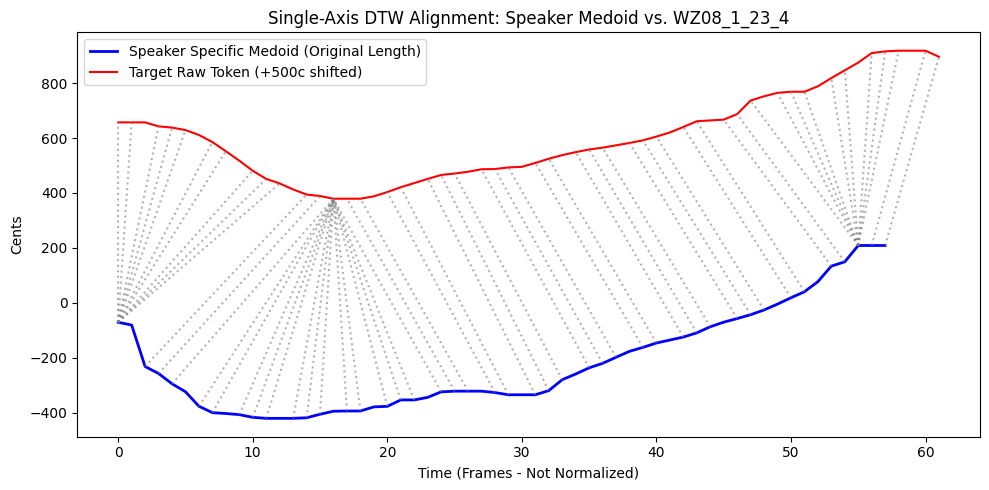

In [129]:
# --- DTW DIAGNOSTIC PLOT ---
# Visualizing how the DTW cleanly warped a raw speaker token against their *exact* Speaker Medoid
target = clean_filenames[0] 
if len(wz_outliers) > 0:
    target = wz_outliers[0][0] # use the worst outlier

# Lookup properties
lookup = plotting_refs[target]
raw_target_contour = lookup['raw']
its_speaker_medoid = lookup['medoid']

plot_dtw_single_axis(its_speaker_medoid, raw_target_contour, f"Single-Axis DTW Alignment: Speaker Medoid vs. {target}")


Random Target Token: WZ13_1_8_2
Its Speaker Medoid:  WZ13_1_16_1


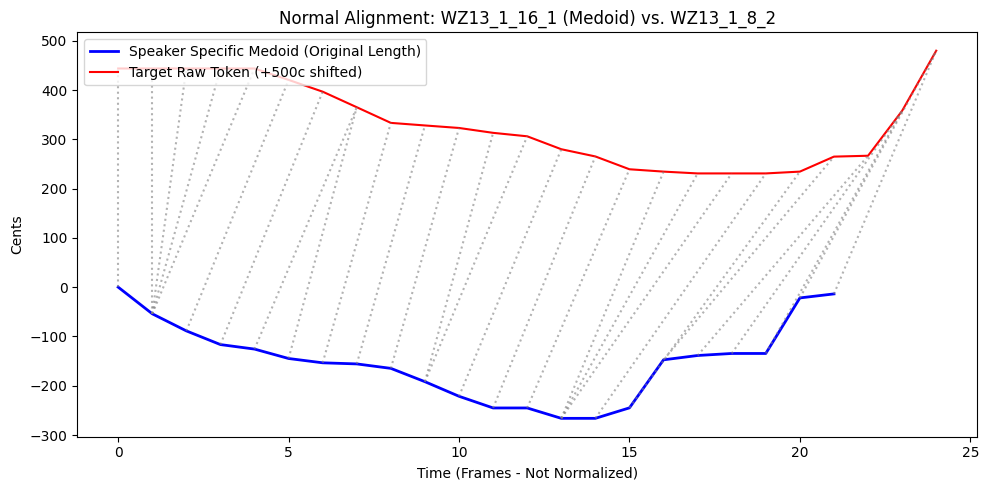

In [130]:
# Plot a random NORMAL token (not an outlier) against its Speaker Medoid to see a clean alignment example
import random
import numpy as np

# 1. Get a list of just the outlier filenames so we can avoid them
outlier_names = [item[0] for item in wz_outliers] 

# 2. Filter the main list to keep only the "normal" tokens
normal_tokens = [fname for fname in clean_filenames if fname not in outlier_names]

# 3. Pick one at random
random_target = random.choice(normal_tokens)

# 4. Lookup properties
lookup = plotting_refs[random_target]
raw_target_contour = lookup['raw']
its_speaker_medoid = lookup['medoid']

# 5. Reverse-lookup the medoid's actual filename!
# The medoid is simply the file whose 'raw' contour is identical to the 'medoid' contour
medoid_filename = "Unknown Medoid"
for fname, refs in plotting_refs.items():
    if np.array_equal(refs['raw'], its_speaker_medoid):
        medoid_filename = fname
        break

print(f"Random Target Token: {random_target}")
print(f"Its Speaker Medoid:  {medoid_filename}")

# 6. Plot it!
plot_title = f"Normal Alignment: {medoid_filename} (Medoid) vs. {random_target}"
plot_dtw_single_axis(its_speaker_medoid, raw_target_contour, plot_title)

--- Building Cross-Dialect Tone Matrix: DZ vs WZ ---

Harvesting DZ SHORT vowels...
Extracting Tone 1 (short vowels) from Tier 2 (N=98)...
✅ Extracted 98 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 2 (short vowels) from Tier 2 (N=137)...
✅ Extracted 137 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 3 (short vowels) from Tier 2 (N=200)...
✅ Extracted 200 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 4 (short vowels) from Tier 2 (N=24)...
✅ Extracted 24 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}


/var/folders/l5/llflwdb53kqbk09mngt_5lc80000gn/T/ipykernel_87006/3458270887.py:91: UserWarning: kernel_size exceeds volume extent: the volume will be zero-padded.
  pitch_cents = scipy.signal.medfilt(pitch_cents, kernel_size=5)


✅ Extracted 294 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 6, 'parselmouth_error': 0}
Extracting Tone 8 (short vowels) from Tier 2 (N=279)...


/var/folders/l5/llflwdb53kqbk09mngt_5lc80000gn/T/ipykernel_87006/3458270887.py:89: UserWarning: kernel_size exceeds volume extent: the volume will be zero-padded.
  pitch_cents = scipy.signal.medfilt(interpolated, kernel_size=5)


✅ Extracted 271 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 8, 'parselmouth_error': 0}
Extracting Tone 9 (short vowels) from Tier 2 (N=0)...
✅ Extracted 0 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 10 (short vowels) from Tier 2 (N=0)...
✅ Extracted 0 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}

Harvesting WZ LONG vowels...
Extracting Tone 1 (long vowels) from Tier 2 (N=464)...
✅ Extracted 464 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 2 (long vowels) from Tier 2 (N=293)...
✅ Extracted 293 contours.
Skipped breakdown: {'no_audio_fil

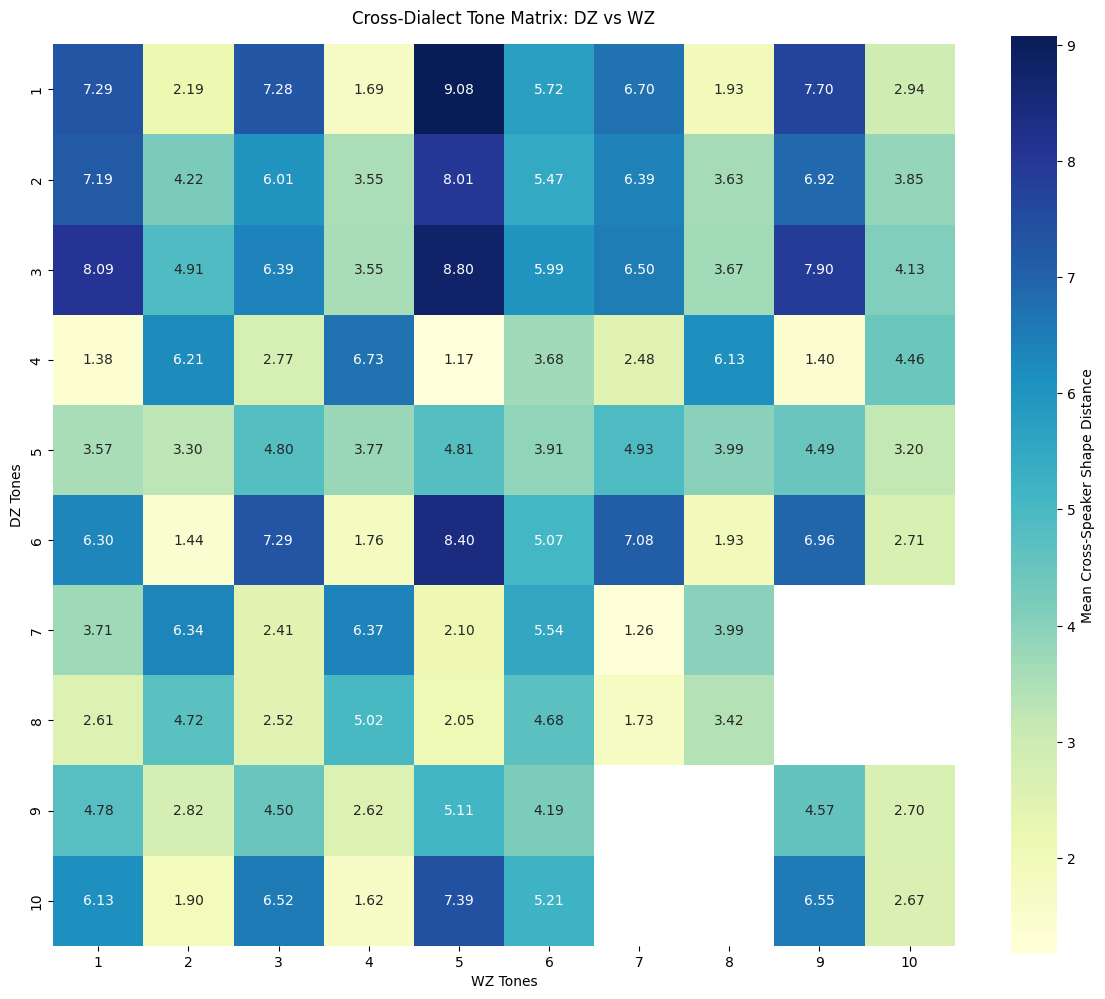

In [131]:
# Similarity matrix comparing tones across dialects
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from dtaidistance import dtw, dtw_barycenter

def get_medoid_index_fast(contours):
    """Uses the optimized C-backend to calculate the pairwise matrix instantly"""
    dist_matrix = dtw.distance_matrix(contours, parallel=True, use_c=True)
    full_matrix = dist_matrix + dist_matrix.T
    avg_dists = np.mean(full_matrix, axis=1)
    return np.argmin(avg_dists)

def build_cross_dialect_tone_matrix(dialect_a='DZ', dialect_b='WZ'):
    print(f"--- Building Cross-Dialect Tone Matrix: {dialect_a} vs {dialect_b} ---")
    
    # 1. Helper function to extract metadata for a specific dialect
    def get_dialect_meta(target_dialect):
        sub = df[(df['Dialect'] == target_dialect) & 
                 (df['Exclude'] == 'Keep') & 
                 (df['DictionaryMatch'] == 'yes')]
        tones = sorted([str(t) for t in sub['ReclassifiedTone'].unique() if str(t) != 'nan'], 
                       key=lambda x: int(x) if x.isdigit() else 99)
        speakers = sorted(list(set(sub['Speaker'].dropna())))
        return tones, speakers

    tones_a, spks_a = get_dialect_meta(dialect_a)
    tones_b, spks_b = get_dialect_meta(dialect_b)
    
    # 2. Master dictionary to hold prototypes for both dialects
    protos = {
        dialect_a: {spk: {'short': {}, 'long': {}} for spk in spks_a},
        dialect_b: {spk: {'short': {}, 'long': {}} for spk in spks_b}
    }
    
    # 3. HARVESTING LOOP (Runs once per Dialect/Length/Tone)
    for current_dialect, dialect_tones, dialect_spks in [(dialect_a, tones_a, spks_a), (dialect_b, tones_b, spks_b)]:
        for vl in ['short', 'long']:
            print(f"\nHarvesting {current_dialect} {vl.upper()} vowels...")
            for tone in dialect_tones:
                contours, fnames = get_dtw_contours_with_textgrids(current_dialect, tone, target_vl=vl)
                if len(contours) == 0:
                    continue
                
                # Distribute to the individual speakers of this dialect
                for spk in dialect_spks:
                    spk_contours = [c for c, f in zip(contours, fnames) if str(f).startswith(spk)]
                    if len(spk_contours) < 3: 
                        continue
                    
                    # Z-Normalize and build the speaker's personal prototype
                    z_contours = [(c - np.mean(c)) / (np.std(c) + 1e-8) for c in spk_contours]
                    medoid_idx = get_medoid_index_fast(z_contours)
                    proto = dtw_barycenter.dba_loop(z_contours, c=z_contours[medoid_idx], max_it=3)
                    
                    protos[current_dialect][spk][vl][tone] = proto

    # 4. CROSS-DIALECT COMPARISON
    print(f"\nCross-comparing {dialect_a} speakers vs. {dialect_b} speakers (controlling for Vowel Length)...")
    
    # Setup matrices where Rows = Dialect A Tones, Columns = Dialect B Tones
    sum_matrix = pd.DataFrame(0.0, index=tones_a, columns=tones_b)
    count_matrix = pd.DataFrame(0.0, index=tones_a, columns=tones_b)
    
    for spk_a in spks_a:
        for spk_b in spks_b:
            # Strictly compare within the same vowel length category
            for vl in ['short', 'long']:
                
                # Iterate through all tones Dialect A speaker produced in this length
                for t_a, p_a in protos[dialect_a][spk_a][vl].items():
                    
                    # Iterate through all tones Dialect B speaker produced in this length
                    for t_b, p_b in protos[dialect_b][spk_b][vl].items():
                        
                        dist = dtw.distance(p_a, p_b)
                        sum_matrix.loc[t_a, t_b] += dist
                        count_matrix.loc[t_a, t_b] += 1

    # 5. AGGREGATION & VISUALIZATION
    print("Aggregating final matrix...")
    master_matrix = sum_matrix / count_matrix.replace(0, np.nan)
    master_matrix = master_matrix.dropna(axis=0, how='all').dropna(axis=1, how='all')
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(master_matrix, annot=True, fmt=".2f", cmap="YlGnBu", 
                cbar_kws={'label': 'Mean Cross-Speaker Shape Distance'})
    
    plt.title(f"Cross-Dialect Tone Matrix: {dialect_a} vs {dialect_b}", pad=15)
    plt.ylabel(f"{dialect_a} Tones")
    plt.xlabel(f"{dialect_b} Tones")
    
    # If both dialects happen to have the exact same number of tone categories, make it a perfect square
    if len(master_matrix.index) == len(master_matrix.columns):
        plt.gca().set_aspect('equal')
        
    plt.tight_layout()
    plt.show()
    
    return master_matrix

# Start the cross-dialect mapping!
cross_dialect_matrix_dz_wz = build_cross_dialect_tone_matrix('DZ', 'WZ')

In [132]:
import sys
import subprocess

# Force install seaborn into the active Jupyter kernel, bypassing the macOS lock
subprocess.check_call([sys.executable, "-m", "pip", "install", "seaborn", "--break-system-packages"])
print("Seaborn successfully installed in the active kernel!")

Seaborn successfully installed in the active kernel!


--- Building Speaker Matrix: WZ Tone 6 (long vowels) ---
Extracting Tone 6 (long vowels) from Tier 2 (N=324)...
✅ Extracted 324 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Successfully harvested 324 tokens. Calculating distance matrix...


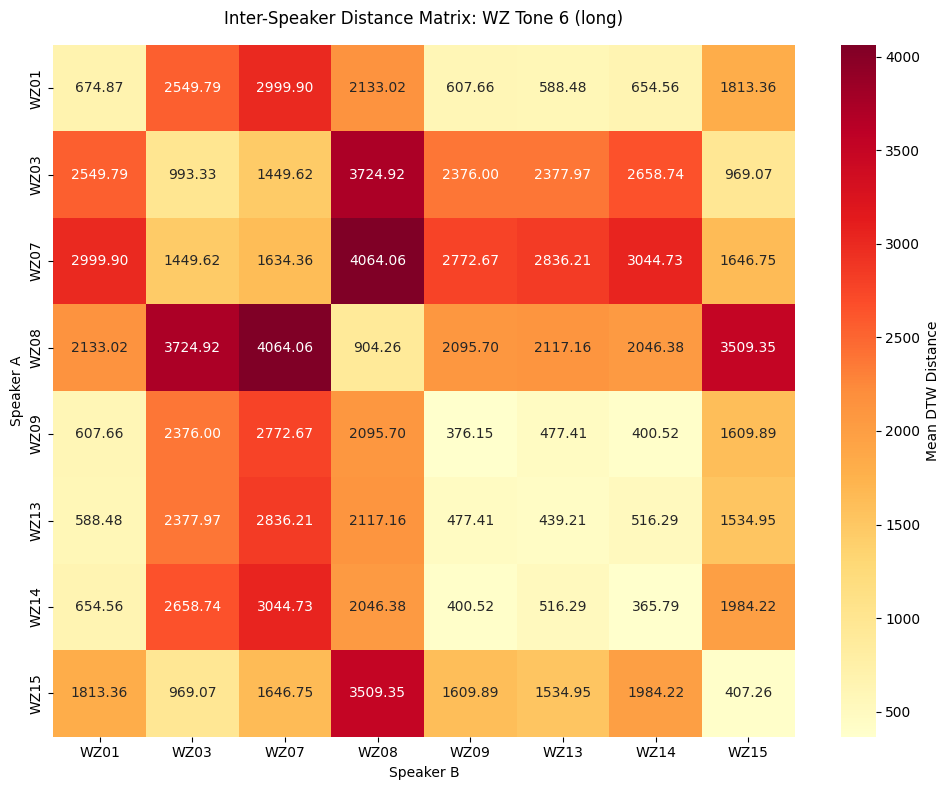

In [133]:
# Calculate the DTW distance matrix between speakers and visualize it as a heatmap
# Customize the combination of dialect, tone, and vowel length
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from dtaidistance import dtw

def build_speaker_distance_matrix_fast(contours, filenames):
    """Optimized version using the C-backend for calculating pairwise token distances"""
    speakers = [fname[:4] for fname in filenames]
    unique_speakers = sorted(list(set(speakers)))
    
    # Calculate the entire pairwise matrix instantly using C
    dist_matrix = dtw.distance_matrix(contours, parallel=True, use_c=True)
    
    # Make it symmetric
    n = len(contours)
    for i in range(n):
        for j in range(i + 1, n):
            dist_matrix[j, i] = dist_matrix[i, j]
        dist_matrix[i, i] = 0.0
        
    dist_df = pd.DataFrame(index=unique_speakers, columns=unique_speakers, dtype=float)
    spk_indices = {spk: [i for i, s in enumerate(speakers) if s == spk] for spk in unique_speakers}
    
    for spk1 in unique_speakers:
        for spk2 in unique_speakers:
            # Mirror to save time
            if pd.notna(dist_df.loc[spk2, spk1]):
                dist_df.loc[spk1, spk2] = dist_df.loc[spk2, spk1]
                continue
                
            idx1 = spk_indices[spk1]
            idx2 = spk_indices[spk2]
            
            if not idx1 or not idx2:
                continue
                
            # Extract the cross-section of distances for just these two speakers
            submatrix = dist_matrix[np.ix_(idx1, idx2)]
            
            if spk1 == spk2:
                # Intra-speaker: Average everything EXCEPT the diagonal (comparing a token to itself)
                if len(idx1) > 1:
                    mask = ~np.eye(len(idx1), dtype=bool)
                    avg_dist = np.mean(submatrix[mask])
                else:
                    avg_dist = 0.0
            else:
                # Inter-speaker: Average the entire block
                avg_dist = np.mean(submatrix)
                
            dist_df.loc[spk1, spk2] = avg_dist
            
    return dist_df

def build_single_tone_speaker_matrix(target_dialect, target_tone, target_vl='long'):
    print(f"--- Building Speaker Matrix: {target_dialect} Tone {target_tone} ({target_vl} vowels) ---")
    
    # 1. Harvest the tokens for this specific tone
    contours, fnames = get_dtw_contours_with_textgrids(target_dialect, str(target_tone), target_vl=target_vl)
    
    if len(contours) == 0:
        print(f"No valid tokens found for Tone {target_tone} ({target_vl}).")
        return None
        
    print(f"Successfully harvested {len(contours)} tokens. Calculating distance matrix...")
    
    # 2. Run the fast C-backed speaker comparison
    matrix = build_speaker_distance_matrix_fast(contours, fnames)
    
    # 3. Visualize
    plt.figure(figsize=(10, 8))
    sns.heatmap(matrix, annot=True, fmt=".2f", cmap="YlOrRd", 
                cbar_kws={'label': 'Mean DTW Distance'})
    
    plt.title(f"Inter-Speaker Distance Matrix: {target_dialect} Tone {target_tone} ({target_vl})", pad=15)
    plt.ylabel("Speaker A")
    plt.xlabel("Speaker B")
    plt.tight_layout()
    plt.show()
    
    return matrix

# Run it by passing the specific tone as an argument!
wz_tone_matrix = build_single_tone_speaker_matrix('WZ', target_tone='6', target_vl='long')

--- Building MASTER Speaker Matrix for DZ (Simple Unweighted Mean) ---
Extracting Tone 1 (long vowels) from Tier 2 (N=301)...
✅ Extracted 301 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Added Tone 1 (long) as 1 structural category.
Extracting Tone 2 (long vowels) from Tier 2 (N=128)...
✅ Extracted 128 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Added Tone 2 (long) as 1 structural category.
Extracting Tone 3 (long vowels) from Tier 2 (N=223)...
✅ Extracted 223 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Added Tone 3 (long) as 1 structural category.
Extracting Tone 4 (long vowels) from Tier 2 (N=153)...
✅ Extracted 153 contours.
Skipped breakdown: {'no

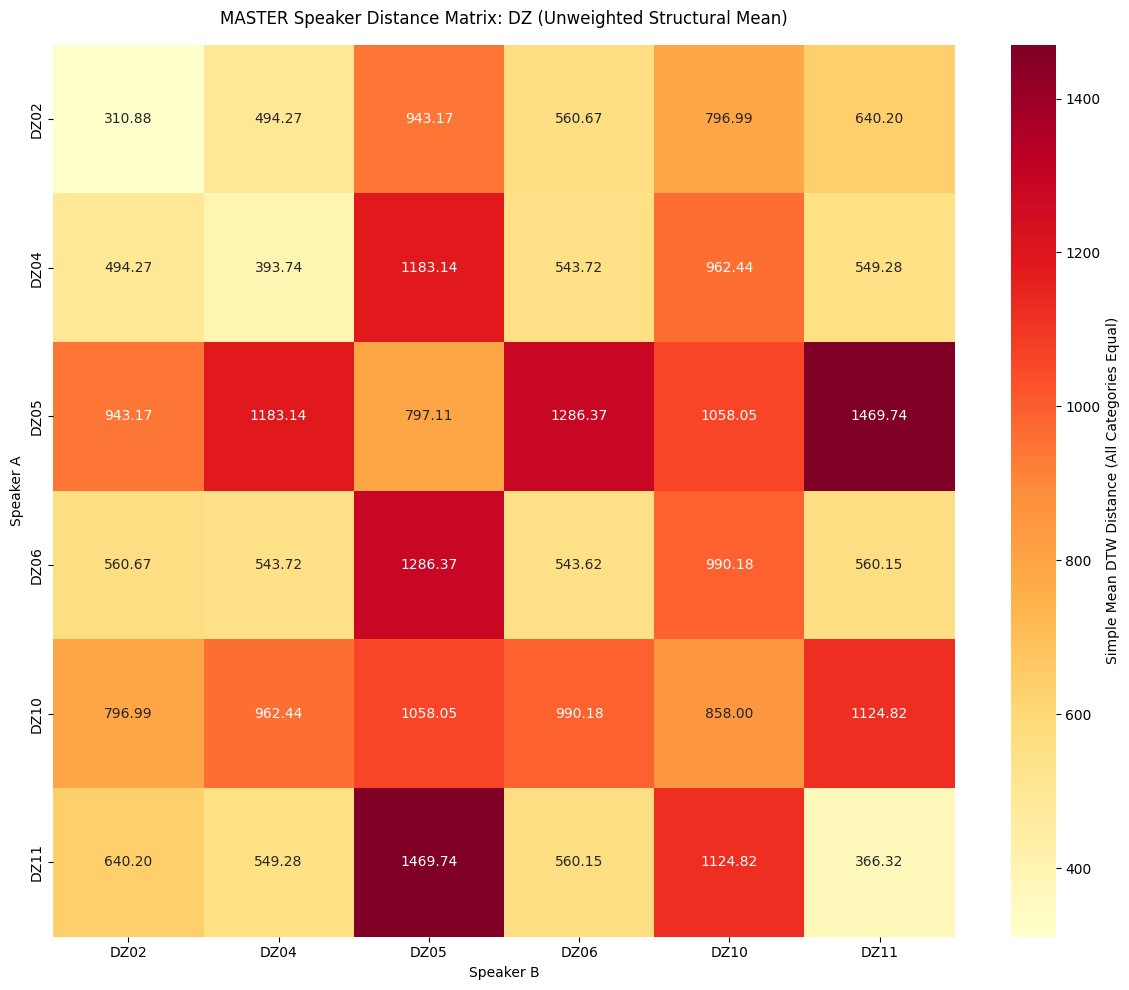

In [137]:
# Get overall speaker similarity by averaging the distances across all tone/length combinations, and visualize it as a heatmap
# Customize the dialect
def build_master_speaker_matrix(target_dialect):
    print(f"--- Building MASTER Speaker Matrix for {target_dialect} (Simple Unweighted Mean) ---")
    
    vowel_lengths = ['long', 'short']
    all_tones = sorted([str(t) for t in df['ReclassifiedTone'].unique() if str(t) != 'nan'], 
                       key=lambda x: int(x) if x.isdigit() else 99)
    
    # 1. Master Speaker List
    master_speakers = sorted(list(set(df[df['Dialect'] == target_dialect]['Speaker'].dropna())))
    
    # 2. Independent tracking matrices
    sum_matrix = pd.DataFrame(0.0, index=master_speakers, columns=master_speakers)
    count_matrix = pd.DataFrame(0.0, index=master_speakers, columns=master_speakers)
    
    for vl in vowel_lengths:
        for tone in all_tones:
            subset = df[(df['Dialect'] == target_dialect) & 
                        (df['ReclassifiedTone'] == tone) &
                        (df['VowelLength'] == vl) & 
                        (df['Exclude'] == 'Keep') &
                        (df['DictionaryMatch'] == 'yes')]
            
            if len(subset) < 20: 
                continue
                
            contours, fnames = get_dtw_contours_with_textgrids(target_dialect, tone, target_vl=vl)
            
            if len(contours) > 0:
                # ---> NOW USING THE FAST FUNCTION <---
                spk_matrix = build_speaker_distance_matrix_fast(contours, fnames)
                
                # 3. Safely add values cell-by-cell (Unweighted)
                for spk1 in spk_matrix.index:
                    for spk2 in spk_matrix.columns:
                        val = spk_matrix.loc[spk1, spk2]
                        if pd.notna(val):
                            sum_matrix.loc[spk1, spk2] += val
                            # Each successfully compared tone category counts as exactly 1 vote
                            count_matrix.loc[spk1, spk2] += 1 
                            
                print(f"Added Tone {tone} ({vl}) as 1 structural category.")
                
    # 4. Final calculation: Simple Mean
    print("\nAggregating matrices cell-by-cell (Simple Mean)...")
    master_matrix = sum_matrix / count_matrix.replace(0, np.nan)
    
    # Visualize the Master Matrix
    plt.figure(figsize=(12, 10))
    sns.heatmap(master_matrix, annot=True, fmt=".2f", cmap="YlOrRd", 
                cbar_kws={'label': 'Simple Mean DTW Distance (All Categories Equal)'})
    
    plt.title(f"MASTER Speaker Distance Matrix: {target_dialect} (Unweighted Structural Mean)", pad=15)
    plt.ylabel("Speaker A")
    plt.xlabel("Speaker B")
    plt.tight_layout()
    plt.show()
    
    return master_matrix

# Start the crunch for Wuming Zhuang
wz_master_matrix = build_master_speaker_matrix('DZ')

--- Comparing DZ Tone 5 vs Tone 7 (short vowels) ---

Harvesting Tone 5...
Extracting Tone 5 (short vowels) from Tier 2 (N=35)...
✅ Extracted 35 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}

Harvesting Tone 7...
Extracting Tone 7 (short vowels) from Tier 2 (N=265)...
✅ Extracted 265 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}

Calculating cross-speaker distances...


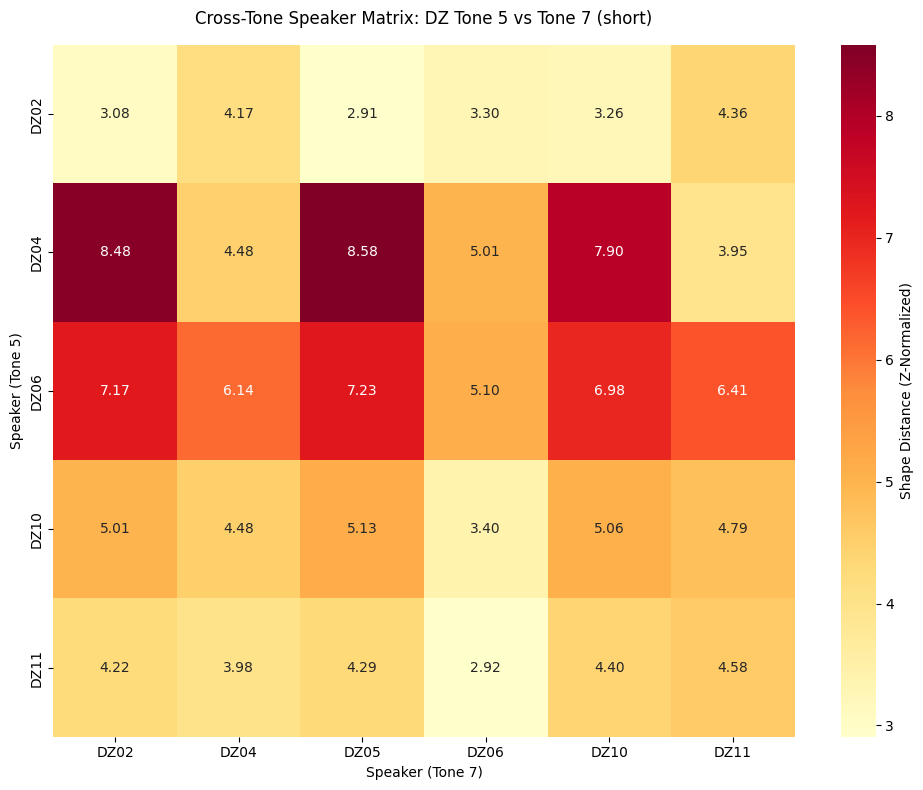

In [ ]:
# For a given pair of tones, look at similarity across speakers
# Customize the dialect, vowel length and tones you want to compare across
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from dtaidistance import dtw, dtw_barycenter

def get_medoid_index_fast(contours):
    """Uses the optimized C-backend to calculate the pairwise matrix instantly"""
    dist_matrix = dtw.distance_matrix(contours, parallel=True, use_c=True)
    full_matrix = dist_matrix + dist_matrix.T
    avg_dists = np.mean(full_matrix, axis=1)
    return np.argmin(avg_dists)

def build_cross_tone_speaker_matrix(target_dialect, tone_a, tone_b, target_vl='long'):
    print(f"--- Comparing {target_dialect} Tone {tone_a} vs Tone {tone_b} ({target_vl} vowels) ---")
    
    # 1. Get a master list of valid speakers for this dialect
    subset = df[(df['Dialect'] == target_dialect) & 
                (df['Exclude'] == 'Keep') &
                (df['DictionaryMatch'] == 'yes')]
    master_speakers = sorted(list(set(subset['Speaker'].dropna())))
    
    protos_a = {}
    protos_b = {}
    
    # 2. Harvest and build personal prototypes for Tone A
    print(f"\nHarvesting Tone {tone_a}...")
    contours_a, fnames_a = get_dtw_contours_with_textgrids(target_dialect, str(tone_a), target_vl)
    
    for spk in master_speakers:
        spk_c = [c for c, f in zip(contours_a, fnames_a) if str(f).startswith(spk)]
        if len(spk_c) >= 3:
            zc = [(c - np.mean(c)) / (np.std(c) + 1e-8) for c in spk_c]
            m_idx = get_medoid_index_fast(zc)
            protos_a[spk] = dtw_barycenter.dba_loop(zc, c=zc[m_idx], max_it=3)
            
    # 3. Harvest and build personal prototypes for Tone B
    print(f"\nHarvesting Tone {tone_b}...")
    contours_b, fnames_b = get_dtw_contours_with_textgrids(target_dialect, str(tone_b), target_vl)
    
    for spk in master_speakers:
        spk_c = [c for c, f in zip(contours_b, fnames_b) if str(f).startswith(spk)]
        if len(spk_c) >= 3:
            zc = [(c - np.mean(c)) / (np.std(c) + 1e-8) for c in spk_c]
            m_idx = get_medoid_index_fast(zc)
            protos_b[spk] = dtw_barycenter.dba_loop(zc, c=zc[m_idx], max_it=3)
            
    # 4. Cross-Compare Tone A vs. Tone B across Speakers
    valid_spk_a = sorted(list(protos_a.keys()))
    valid_spk_b = sorted(list(protos_b.keys()))
    
    if not valid_spk_a or not valid_spk_b:
        print("Not enough data to compare these two tones.")
        return None
        
    print("\nCalculating cross-speaker distances...")
    matrix = pd.DataFrame(np.nan, index=valid_spk_a, columns=valid_spk_b)
    
    for spk_a in valid_spk_a:
        for spk_b in valid_spk_b:
            dist = dtw.distance(protos_a[spk_a], protos_b[spk_b])
            matrix.loc[spk_a, spk_b] = dist
            
    # 5. Visualize
    plt.figure(figsize=(10, 8))
    sns.heatmap(matrix, annot=True, fmt=".2f", cmap="YlOrRd", 
                cbar_kws={'label': 'Shape Distance (Z-Normalized)'})
    
    plt.title(f"Cross-Tone Speaker Matrix: {target_dialect} Tone {tone_a} vs Tone {tone_b} ({target_vl})", pad=15)
    plt.ylabel(f"Speaker (Tone {tone_a})")
    plt.xlabel(f"Speaker (Tone {tone_b})")
    
    if len(matrix.index) == len(matrix.columns):
        plt.gca().set_aspect('equal')
        
    plt.tight_layout()
    plt.show()
    
    return matrix

# Run it with choice of dialect, tone pair and vowel length
tone_comparison_matrix = build_cross_tone_speaker_matrix(
    target_dialect='DZ', 
    tone_a='5', 
    tone_b='7', 
    target_vl='short'
)

--- Building Speaker-Controlled Inter-Tone Matrix for WZ (Duration Ignored) ---
Harvesting Tone 1 (pooling short & long vowels)...
Extracting Tone 1 (short vowels) from Tier 2 (N=193)...
✅ Extracted 193 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 1 (long vowels) from Tier 2 (N=464)...
✅ Extracted 464 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Harvesting Tone 2 (pooling short & long vowels)...
Extracting Tone 2 (short vowels) from Tier 2 (N=155)...
✅ Extracted 155 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 2 (long vowels) from Tier 2 (N=293)...
✅ Extracted 293 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_text

/var/folders/l5/llflwdb53kqbk09mngt_5lc80000gn/T/ipykernel_87006/3458270887.py:91: UserWarning: kernel_size exceeds volume extent: the volume will be zero-padded.
  pitch_cents = scipy.signal.medfilt(pitch_cents, kernel_size=5)


✅ Extracted 294 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 6, 'parselmouth_error': 0}
Extracting Tone 7 (long vowels) from Tier 2 (N=0)...
✅ Extracted 0 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Harvesting Tone 8 (pooling short & long vowels)...
Extracting Tone 8 (short vowels) from Tier 2 (N=279)...


/var/folders/l5/llflwdb53kqbk09mngt_5lc80000gn/T/ipykernel_87006/3458270887.py:89: UserWarning: kernel_size exceeds volume extent: the volume will be zero-padded.
  pitch_cents = scipy.signal.medfilt(interpolated, kernel_size=5)


✅ Extracted 271 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 8, 'parselmouth_error': 0}
Extracting Tone 8 (long vowels) from Tier 2 (N=0)...
✅ Extracted 0 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Harvesting Tone 9 (pooling short & long vowels)...
Extracting Tone 9 (short vowels) from Tier 2 (N=0)...
✅ Extracted 0 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 9 (long vowels) from Tier 2 (N=212)...
✅ Extracted 211 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 1, 'parselmouth_error': 0}
Harvesting Tone 10 (pooling short & long vowels)...
Extracting Tone 10 (short vowels) from Tier

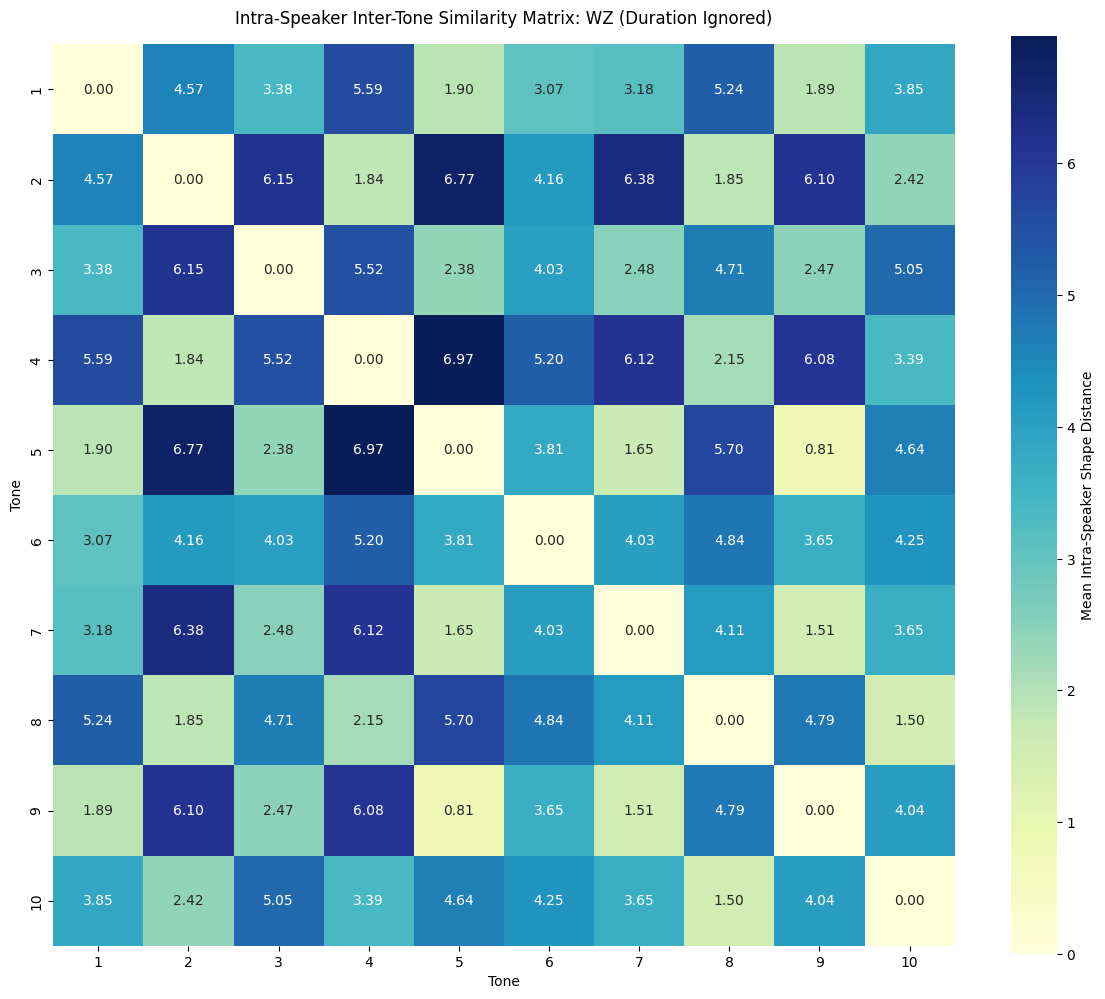

In [139]:
# Compare inter-tone similarity across speakers
# Customize the dialect
import itertools
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from dtaidistance import dtw, dtw_barycenter

def get_medoid_index_fast(contours):
    """Uses the optimized C-backend to calculate the pairwise matrix instantly"""
    dist_matrix = dtw.distance_matrix(contours, parallel=True, use_c=True)
    full_matrix = dist_matrix + dist_matrix.T
    avg_dists = np.mean(full_matrix, axis=1)
    return np.argmin(avg_dists)

def build_speaker_controlled_inter_tone_matrix(target_dialect):
    print(f"--- Building Speaker-Controlled Inter-Tone Matrix for {target_dialect} (Duration Ignored) ---")
    
    # 1. Get baseline data
    subset = df[(df['Dialect'] == target_dialect) & 
                (df['Exclude'] == 'Keep') &
                (df['DictionaryMatch'] == 'yes')]
    
    all_tones = sorted([str(t) for t in subset['ReclassifiedTone'].unique() if str(t) != 'nan'], 
                       key=lambda x: int(x) if x.isdigit() else 99)
    master_speakers = sorted(list(set(subset['Speaker'].dropna())))
    
    # Initialize a master dictionary to hold every speaker's unified prototypes
    spk_protos = {spk: {} for spk in master_speakers}
    
    # 2. HARVEST ONCE (Pooling both lengths)
    for tone in all_tones:
        print(f"Harvesting Tone {tone} (pooling short & long vowels)...")
        
        all_tone_contours = []
        all_tone_fnames = []
        
        # Safely pull and pool both lengths using your existing harvester
        for vl in ['short', 'long']:
            contours, fnames = get_dtw_contours_with_textgrids(target_dialect, tone, target_vl=vl)
            all_tone_contours.extend(contours)
            all_tone_fnames.extend(fnames)
            
        if len(all_tone_contours) == 0:
            continue
            
        # Distribute the pooled data to the individual speakers
        for spk in master_speakers:
            spk_contours = [c for c, f in zip(all_tone_contours, all_tone_fnames) if str(f).startswith(spk)]
            
            if len(spk_contours) < 3: # Need at least 3 combined tokens for a valid prototype
                continue
            
            # Z-Normalize and build the unified personal prototype
            z_contours = [(c - np.mean(c)) / (np.std(c) + 1e-8) for c in spk_contours]
            medoid_idx = get_medoid_index_fast(z_contours)
            proto = dtw_barycenter.dba_loop(z_contours, c=z_contours[medoid_idx], max_it=3)
            
            spk_protos[spk][tone] = proto
            
    # 3. CROSS-COMPARE within each speaker's personal geometry
    print("\nCross-comparing intra-speaker prototypes...")
    sum_matrix = pd.DataFrame(0.0, index=all_tones, columns=all_tones)
    count_matrix = pd.DataFrame(0.0, index=all_tones, columns=all_tones)
    
    for spk in master_speakers:
        tones_present = list(spk_protos[spk].keys())
        
        # Compare every valid tone against every other valid tone for this speaker
        for t1, t2 in itertools.combinations_with_replacement(tones_present, 2):
            dist = dtw.distance(spk_protos[spk][t1], spk_protos[spk][t2])
            
            # Since Tone 1 vs Tone 2 is identical to Tone 2 vs Tone 1, mirror the results
            sum_matrix.loc[t1, t2] += dist
            count_matrix.loc[t1, t2] += 1
            
            if t1 != t2:
                sum_matrix.loc[t2, t1] += dist
                count_matrix.loc[t2, t1] += 1
                
    # 4. Calculate Final Averages
    print("Aggregating final matrix...")
    master_matrix = sum_matrix / count_matrix.replace(0, np.nan)
    master_matrix = master_matrix.dropna(axis=0, how='all').dropna(axis=1, how='all')
    
    # 5. Visualize
    plt.figure(figsize=(12, 10))
    sns.heatmap(master_matrix, annot=True, fmt=".2f", cmap="YlGnBu", 
                cbar_kws={'label': 'Mean Intra-Speaker Shape Distance'})
    
    plt.title(f"Intra-Speaker Inter-Tone Similarity Matrix: {target_dialect} (Duration Ignored)", pad=15)
    plt.ylabel("Tone")
    plt.xlabel("Tone")
    
    # Force a perfect square since axes are identical
    plt.gca().set_aspect('equal')
    plt.tight_layout()
    plt.show()
    
    return master_matrix

# Run it for the chosen dialect!
pure_tone_matrix = build_speaker_controlled_inter_tone_matrix('WZ')

--- Building Speaker-Controlled Cross-Length Matrix for WZ (Using 100% of data) ---

Harvesting all SHORT vowels...
Extracting Tone 1 (short vowels) from Tier 2 (N=193)...
✅ Extracted 193 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 2 (short vowels) from Tier 2 (N=155)...
✅ Extracted 155 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 3 (short vowels) from Tier 2 (N=283)...
✅ Extracted 283 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 4 (short vowels) from Tier 2 (N=29)...
✅ Extracted 29 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_s

/var/folders/l5/llflwdb53kqbk09mngt_5lc80000gn/T/ipykernel_87006/3458270887.py:91: UserWarning: kernel_size exceeds volume extent: the volume will be zero-padded.
  pitch_cents = scipy.signal.medfilt(pitch_cents, kernel_size=5)


✅ Extracted 294 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 6, 'parselmouth_error': 0}
Extracting Tone 8 (short vowels) from Tier 2 (N=279)...


/var/folders/l5/llflwdb53kqbk09mngt_5lc80000gn/T/ipykernel_87006/3458270887.py:89: UserWarning: kernel_size exceeds volume extent: the volume will be zero-padded.
  pitch_cents = scipy.signal.medfilt(interpolated, kernel_size=5)


✅ Extracted 271 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 8, 'parselmouth_error': 0}
Extracting Tone 9 (short vowels) from Tier 2 (N=0)...
✅ Extracted 0 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 10 (short vowels) from Tier 2 (N=0)...
✅ Extracted 0 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}

Harvesting all LONG vowels...
Extracting Tone 1 (long vowels) from Tier 2 (N=464)...
✅ Extracted 464 contours.
Skipped breakdown: {'no_audio_file': 0, 'no_textgrid_file': 0, 'tier1_has_no_labeled_intervals': 0, 'contour_too_short': 0, 'parselmouth_error': 0}
Extracting Tone 2 (long vowels) from Tier 2 (N=293)...
✅ Extracted 293 contours.
Skipped breakdown: {'no_audio_fi

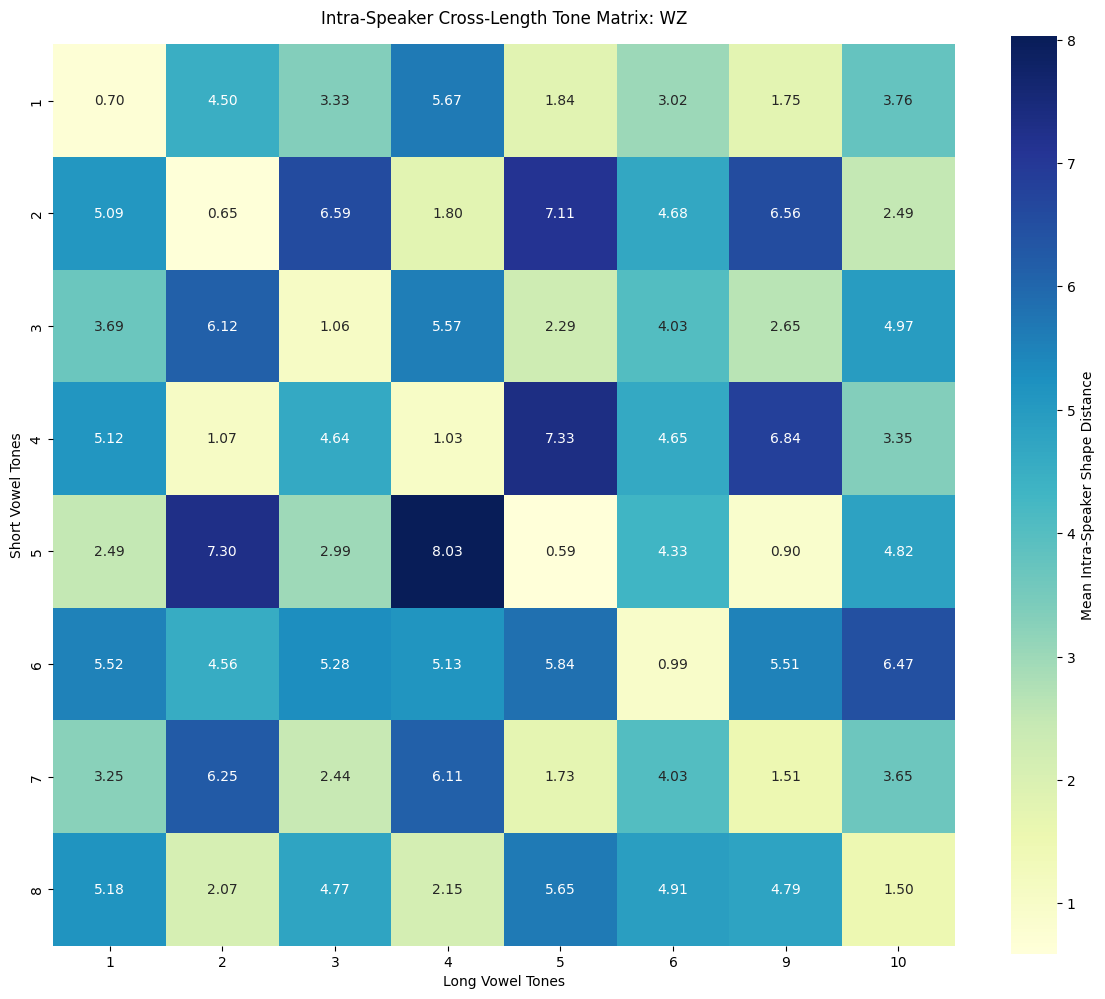

In [ ]:
# Look at inter-tone similarity comparing short tones against long tones
# Customize by dialect
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from dtaidistance import dtw, dtw_barycenter

def get_medoid_index_fast(contours):
    """Uses the optimized C-backend to calculate the pairwise matrix instantly"""
    dist_matrix = dtw.distance_matrix(contours, parallel=True, use_c=True)
    full_matrix = dist_matrix + dist_matrix.T
    avg_dists = np.mean(full_matrix, axis=1)
    return np.argmin(avg_dists)

def build_speaker_controlled_cross_length_matrix(target_dialect):
    print(f"--- Building Speaker-Controlled Cross-Length Matrix for {target_dialect} (Using 100% of data) ---")
    
    # 1. Get baseline data
    subset = df[(df['Dialect'] == target_dialect) & 
                (df['Exclude'] == 'Keep') &
                (df['DictionaryMatch'] == 'yes')]
    
    all_tones = sorted([str(t) for t in subset['ReclassifiedTone'].unique() if str(t) != 'nan'], 
                       key=lambda x: int(x) if x.isdigit() else 99)
    master_speakers = sorted(list(set(subset['Speaker'].dropna())))
    
    # Initialize a master dictionary to hold every speaker's prototypes
    spk_protos = {spk: {'short': {}, 'long': {}} for spk in master_speakers}
    
    # 2. OPTIMIZATION: Loop by Tone/Length FIRST, harvest ONCE
    for vl in ['short', 'long']:
        print(f"\nHarvesting all {vl.upper()} vowels...")
        for tone in all_tones:
            # Harvest the entire dialect for this specific tone/length combination
            contours, fnames = get_dtw_contours_with_textgrids(target_dialect, tone, target_vl=vl)
            
            if len(contours) == 0:
                continue
                
            # Now, distribute the harvested data to the individual speakers
            for spk in master_speakers:
                spk_contours = [c for c, f in zip(contours, fnames) if str(f).startswith(spk)]
                
                if len(spk_contours) < 3: # Need at least 3 tokens for a valid prototype
                    continue
                
                # Z-Normalize and build prototype
                z_contours = [(c - np.mean(c)) / (np.std(c) + 1e-8) for c in spk_contours]
                
                # Fast medoid calculation
                medoid_idx = get_medoid_index_fast(z_contours)
                
                # Calculate Barycenter (keeping max_it=3 as it converges quickly)
                proto = dtw_barycenter.dba_loop(z_contours, c=z_contours[medoid_idx], max_it=3)
                spk_protos[spk][vl][tone] = proto
                
    # 3. Cross-compare within each speaker's personal geometry
    print("\nCross-comparing intra-speaker prototypes...")
    sum_matrix = pd.DataFrame(0.0, index=all_tones, columns=all_tones)
    count_matrix = pd.DataFrame(0.0, index=all_tones, columns=all_tones)
    
    for spk in master_speakers:
        for t_short, p_short in spk_protos[spk]['short'].items():
            for t_long, p_long in spk_protos[spk]['long'].items():
                dist = dtw.distance(p_short, p_long)
                sum_matrix.loc[t_short, t_long] += dist
                count_matrix.loc[t_short, t_long] += 1
                
    # 4. Calculate Final Averages
    print("Aggregating final matrix...")
    master_matrix = sum_matrix / count_matrix.replace(0, np.nan)
    master_matrix = master_matrix.dropna(axis=0, how='all').dropna(axis=1, how='all')
    
    # 5. Visualize
    plt.figure(figsize=(12, 10))
    sns.heatmap(master_matrix, annot=True, fmt=".2f", cmap="YlGnBu", 
                cbar_kws={'label': 'Mean Intra-Speaker Shape Distance'})
    
    plt.title(f"Intra-Speaker Cross-Length Tone Matrix: {target_dialect}", pad=15)
    plt.ylabel("Short Vowel Tones")
    plt.xlabel("Long Vowel Tones")
    
    if len(master_matrix.index) == len(master_matrix.columns):
        plt.gca().set_aspect('equal')
        
    plt.tight_layout()
    plt.show()
    
    return master_matrix

# Run it!
speaker_controlled_matrix = build_speaker_controlled_cross_length_matrix('DZ')